<a href="https://colab.research.google.com/github/kanonlas/catsNdogs/blob/main/CDtest_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GPU setting

**before run changing CPU to GPU first **

1. Runtime
2. Change runtime type
3. Hardware accelerator
4. GPU
5. Save





In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
print(torch.cuda.get_device_name(0))
# checking GPU รุ่น

Tesla T4


# เตรียม Library

After check the GPU installing library for model machine learning

In [3]:
!pip install torch torchvision matplotlib scikit-learn

transforms ใช้สำหรับ เตรียม/แปลงรูปก่อนส่งเข้า AI


---


ส่วน Subset ในโปรเจกต์เรามี:

8,005 training images

เราอยากแบ่งเป็น:

80% → Train
20% → Validation

เราจึงใช้ Subset เพื่อบอกว่า:

"เอาเฉพาะรูปที่อยู่ใน index เหล่านี้มาเป็น training dataset"

In [55]:
import torch #framework หลักที่เราใช้สร้างและ train AI
import torchvision #Computer Vision บน PyTorch
import matplotlib.pyplot as plt #แสดงผลภาพและสร้างกราฟ

from torchvision import datasets, transforms #ให้โหลดแค่สองอันนี้ที่ใช้พอ
from torch.utils.data import DataLoader #dataset มาแบ่งเป็น batch
from torch.utils.data import Subset #เลือกบางส่วนของ dataset

In [23]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

# result = cuda ; GPU is already

cuda


# Load Dataset

In [11]:
import kagglehub

path = kagglehub.dataset_download("tongpython/cat-and-dog")

print("Path to dataset files:", path)

100%|██████████| 218M/218M [00:11<00:00, 20.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1


In [12]:
import os # Import the os module to work with files and directories
print(os.listdir(path))

['test_set', 'training_set']


In [32]:
print(os.listdir(f"{path}/training_set/training_set"))

['dogs', 'cats']


# Define Transforms

🖼️ Image Transformations

ใช้ `torchvision.transforms` เพื่อเตรียมและปรับแต่งรูปภาพก่อนนำเข้าโมเดล

---

 🔹 `transforms.Compose()`

รวมขั้นตอนการแปลงรูปภาพหลายขั้นตอนให้ทำงานต่อกันตามลำดับ

---

🔹 `transforms.Resize((224, 224))`

ปรับขนาดรูปภาพทุกภาพให้เป็น **224 × 224 pixels**

> 📌 เพื่อให้รูปภาพทั้งหมดมีขนาดเท่ากันก่อนนำเข้าโมเดล

---

🔹 `transforms.RandomHorizontalFlip()`

สุ่มพลิกรูปภาพในแนวนอน **(ซ้าย ↔ ขวา)**

> 📌 ช่วยเพิ่มความหลากหลายของข้อมูล และช่วยลดปัญหา **Overfitting**

---

🔹 `transforms.RandomRotation(10)`

สุ่มหมุนรูปภาพได้สูงสุดประมาณ **±10°**

> 📌 ช่วยให้โมเดลเรียนรู้รูปภาพที่มีมุมหรือทิศทางแตกต่างกัน

---

🔹 `transforms.ToTensor()`

แปลงรูปภาพจากรูปแบบภาพทั่วไปให้เป็น **PyTorch Tensor**



In [38]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Validation มีหน้าที่ช่วยเราตัดสินใจว่าโมเดลกำลังเรียนรู้ดีแค่ไหนระหว่างการ Train โดยที่เราไม่เอา Test set มายุ่งจนกว่าจะถึงตอนสุดท้าย


after define transform the data we will load data into our model process

In [39]:
full_dataset = datasets.ImageFolder(
    f"{path}/training_set/training_set"
)

test_dataset = datasets.ImageFolder(
    f"{path}/test_set",
    transform=val_test_transform
)

print("Classes:", full_dataset.classes)
print("Total training images:", len(full_dataset))
print("Total test images:", len(test_dataset))

Classes: ['cats', 'dogs']
Total training images: 8005
Total test images: 2023


# Split Training / Validation

เราจะเอา training dataset แบ่งเป็น:

1.   80% → Train
2.   20% → Validation





In [40]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_indices, val_indices = random_split(
    range(len(full_dataset)),
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train:", len(train_indices))
print("Validation:", len(val_indices))

# manual_seed(42) ทำให้การสุ่มแบ่ง dataset เหมือนเดิมทุกครั้ง ที่รัน ปลเลขไรก็ได้ใส่ไปเถอะ

Train: 6404
Validation: 1601


หลังจากแบ่งข้อมูลแล้วเราก็ต้องมาสร้าง dataset Train / Validation เพื่อให้เราได้



*  train_dataset
*  val_dataset
*  test_dataset


In [41]:
train_full = datasets.ImageFolder(
    f"{path}/training_set",
    transform=train_transform  #เลขรูป all
)

val_full = datasets.ImageFolder(
    f"{path}/training_set",
    transform=val_test_transform
)

#รูปที่หยิบออกมา เป็นซับเซตของ รูปทั้งหมด เเละรูปที่สุ่มเลือก
train_dataset = Subset(
    train_full,
    train_indices.indices #รูปที่เลือก
)

val_dataset = Subset(
    val_full,
    val_indices.indices
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 6404
Validation: 1601
Test: 2023


# DataLoader

| Batch size | ข้อดี                | ข้อเสีย                |
| ---------- | -------------------- | ---------------------- |
| `16`       | ใช้ GPU memory น้อย  | Train ช้ากว่า          |
| **`32`** ⭐ | สมดุล                | -                      |
| `64`       | เร็วขึ้นได้          | ใช้ GPU memory มากขึ้น |
| `128`      | ประมวลผลเยอะต่อครั้ง | ใช้ GPU memory เยอะ    |


In [42]:
# ต่อไปให้ DataLoader จัดการ batch:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False # ไม่ต้องสุ่มเพราะไม่ได้เอาข้อมูลนี้ไปเทรน
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("DataLoaders are ready!")

DataLoaders are ready!


ตรวจสอบรูปก่อน Train （ก่อนสร้าง ResNet18）

In [43]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label shape:", labels.shape)
print("Labels:", labels[:10])

# 32  → จำนวนรูป
# 3   → RGB channels
# 224 → height
# 224 → width

Image batch shape: torch.Size([32, 3, 224, 224])
Label shape: torch.Size([32])
Labels: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


try to preview picture

In [46]:
print(full_dataset.classes)
print(full_dataset.class_to_idx)
# ตรวจให้แน่ใจก่อนว่า dataset มี class cats และ dogs จริง ๆ

['cats', 'dogs']
{'cats': 0, 'dogs': 1}


In [56]:
# print("Total:", len(full_dataset))

# # Check labels at different positions
# for i in [0, 100, 1000, 5000, 10000, 15000, 20000]:
#     if i < len(full_dataset): # เช็กก่อนว่า index นี้มีอยู่จริง
#         _, label = full_dataset[i] #เอา Label ของรูปนั้นออกมา
#         print(i, label, full_dataset.classes[label])

# # 1.เช็กว่ามีรูปทั้งหมดกี่รูป
# # 2.ลองเช็กรูปที่อยู่คนละตำแหน่ง

import random

# สุ่ม index จำนวน 10 รูปจาก Dataset
random_indices = random.sample(
    range(len(full_dataset)),
    10
)

# ตรวจสอบ label ของรูปที่สุ่มได้
for i in random_indices:
    _, label = full_dataset[i]
    print(i, label, full_dataset.classes[label])


112 0 cats
7066 1 dogs
4846 1 dogs
2835 0 cats
5162 1 dogs
5060 1 dogs
2704 0 cats
7397 1 dogs
236 0 cats
4269 1 dogs


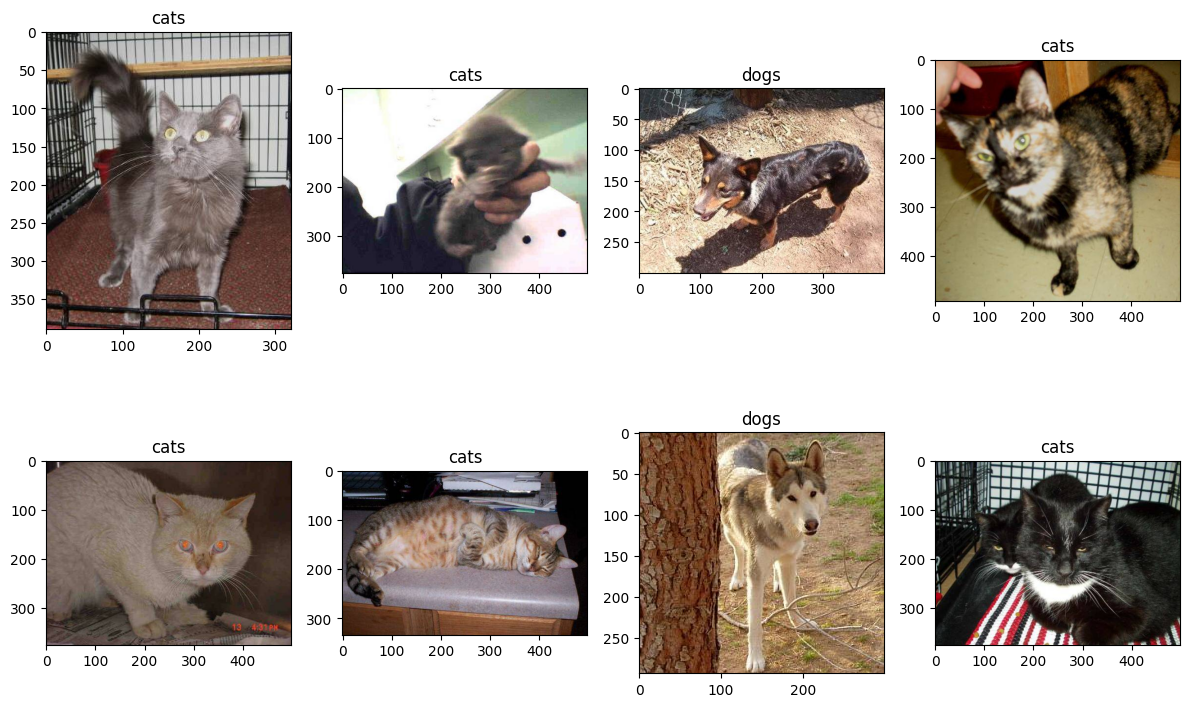

In [59]:
plt.figure(figsize=(12, 8))   #สร้างพื้นที่สำหรับแสดงรูปกว้าง 12 × สูง 8

indices = random.sample(range(len(full_dataset)),8)

for i, idx in enumerate(indices):
    image, label = full_dataset[idx]

    # ImageFolder returns PIL image here
    plt.subplot(2, 4, i + 1) # 2 แถว × 4 คอลัมน์
    plt.imshow(image)
    plt.title(full_dataset.classes[label]) # เขียนชื่อ Class ไว้เหนือรูป
    plt.axis("on") # ซ่อนแกนของกราฟ

plt.tight_layout()
plt.show()